In [3]:
import pandas as pd

national_detailed = pd.read_excel(r"C:\Users\admin\Desktop\BLS Project\cleaned\detailed\national_detailed.xlsx")
state_detailed = pd.read_excel(r"C:\Users\admin\Desktop\BLS Project\cleaned\detailed\state_detailed.xlsx")
msa_detailed = pd.read_excel(r"C:\Users\admin\Desktop\BLS Project\cleaned\detailed\msa_detailed.xlsx")
bos_detailed = pd.read_excel(r"C:\Users\admin\Desktop\BLS Project\cleaned\detailed\bos_detailed.xlsx")
ep_detailed = pd.read_excel(r"C:\Users\admin\Desktop\BLS Project\cleaned\detailed\employment_projections_detailed.xlsx")
openings_detailed = pd.read_excel(r"C:\Users\admin\Desktop\BLS Project\cleaned\detailed\openings_detailed.xlsx")

In [4]:
national_detailed.shape

(830, 32)

In [5]:
state_detailed.shape

(36168, 34)

In [6]:
msa_detailed.shape

(141015, 34)

In [7]:
bos_detailed.shape

(45542, 34)

In [8]:
ep_detailed.shape

(831, 17)

In [9]:
openings_detailed.shape

(831, 14)

In [10]:
national_subset = national_detailed[["OCC_CODE", "OCC_TITLE", "TOT_EMP", "A_MEDIAN"]].copy()

ep_subset = ep_detailed[["2025 National Employment Matrix code", "2025 National Employment Matrix title", "Employment, 2025","Employment, 2035", "Employment change, numeric, 2025–35",
"Employment change, percent, 2025–35", "Occupational openings, 2025–35 annual average", "Typical education needed for entry",
"Work experience in a related occupation", "Typical on-the-job training needed to attain competency in the occupation"]].copy()

openings_subset = openings_detailed[["2025 National Employment Matrix code", "2025 National Employment Matrix title", "Labor force exit rate, 2025–35 annual average",
"Occupational transfer rate, 2025–35 annual average", "Total occupational separations, 2025–35 annual average",
"Labor force exits, 2025–35 annual average", "Occupational transfers, 2025–35 annual average"]].copy()

In [11]:
print("National dataset number of rows: ", national_subset.shape)
print("Employement Projections dataset number of rows: ", ep_subset.shape)
print("Openings dataset number of rows: ", openings_subset.shape)

National dataset number of rows:  (830, 4)
Employement Projections dataset number of rows:  (831, 10)
Openings dataset number of rows:  (831, 7)


In [12]:
#Finding the missing occupation in the national dataset
national_codes = set(national_subset["OCC_CODE"])
ep_codes = set(ep_subset["2025 National Employment Matrix code"])
openings_codes = set(openings_subset["2025 National Employment Matrix code"])

print("In EP but not National: ", ep_codes - national_codes)

In EP but not National:  {'45-3031'}


In [13]:
ep_subset[ep_subset["2025 National Employment Matrix code"] == "45-3031"]["2025 National Employment Matrix title"]

559          Fishing and hunting workers
Name: 2025 National Employment Matrix title, dtype: object

In [14]:
#Renaming the primary key column for a safe merge
ep_subset = ep_subset.rename(columns={"2025 National Employment Matrix code": "OCC_CODE"})
openings_subset = openings_subset.rename(columns={"2025 National Employment Matrix code": "OCC_CODE"})

In [15]:
print("National columns :", national_subset.columns)
print("Ep columns :", ep_subset.columns)
print("Openings columns :", openings_subset.columns)

National columns : Index(['OCC_CODE', 'OCC_TITLE', 'TOT_EMP', 'A_MEDIAN'], dtype='object')
Ep columns : Index(['OCC_CODE', '2025 National Employment Matrix title', 'Employment, 2025',
       'Employment, 2035', 'Employment change, numeric, 2025–35',
       'Employment change, percent, 2025–35',
       'Occupational openings, 2025–35 annual average',
       'Typical education needed for entry',
       'Work experience in a related occupation',
       'Typical on-the-job training needed to attain competency in the occupation'],
      dtype='object')
Openings columns : Index(['OCC_CODE', '2025 National Employment Matrix title',
       'Labor force exit rate, 2025–35 annual average',
       'Occupational transfer rate, 2025–35 annual average',
       'Total occupational separations, 2025–35 annual average',
       'Labor force exits, 2025–35 annual average',
       'Occupational transfers, 2025–35 annual average'],
      dtype='object')


In [16]:
ml_data = national_subset.merge(ep_subset, on="OCC_CODE", how="inner")
ml_data = ml_data.merge(openings_subset, on="OCC_CODE", how="inner")

print("ML dataset rows & column count: ", ml_data.shape)
print("ML dataset columns: ", ml_data.columns)

ML dataset rows & column count:  (830, 19)
ML dataset columns:  Index(['OCC_CODE', 'OCC_TITLE', 'TOT_EMP', 'A_MEDIAN',
       '2025 National Employment Matrix title_x', 'Employment, 2025',
       'Employment, 2035', 'Employment change, numeric, 2025–35',
       'Employment change, percent, 2025–35',
       'Occupational openings, 2025–35 annual average',
       'Typical education needed for entry',
       'Work experience in a related occupation',
       'Typical on-the-job training needed to attain competency in the occupation',
       '2025 National Employment Matrix title_y',
       'Labor force exit rate, 2025–35 annual average',
       'Occupational transfer rate, 2025–35 annual average',
       'Total occupational separations, 2025–35 annual average',
       'Labor force exits, 2025–35 annual average',
       'Occupational transfers, 2025–35 annual average'],
      dtype='object')


In [17]:
#Dropping redundant column

ml_data = ml_data.drop(columns=["2025 National Employment Matrix title_y"])

ml_data = ml_data.rename(columns={"2025 National Employment Matrix title_x":"2025 National Employment Matrix title"})

ml_data.columns

Index(['OCC_CODE', 'OCC_TITLE', 'TOT_EMP', 'A_MEDIAN',
       '2025 National Employment Matrix title', 'Employment, 2025',
       'Employment, 2035', 'Employment change, numeric, 2025–35',
       'Employment change, percent, 2025–35',
       'Occupational openings, 2025–35 annual average',
       'Typical education needed for entry',
       'Work experience in a related occupation',
       'Typical on-the-job training needed to attain competency in the occupation',
       'Labor force exit rate, 2025–35 annual average',
       'Occupational transfer rate, 2025–35 annual average',
       'Total occupational separations, 2025–35 annual average',
       'Labor force exits, 2025–35 annual average',
       'Occupational transfers, 2025–35 annual average'],
      dtype='object')

In [18]:
#Basic duplication sanity check
ml_data.duplicated().sum()

np.int64(0)

In [19]:
ml_data["2025 National Employment Matrix title"].nunique()

830

In [20]:
#Feature engineering openings rate column
ml_data["OPENINGS_RATE"] = (ml_data["Occupational openings, 2025–35 annual average"]/ml_data["Employment, 2025"]) * 100

In [21]:
ml_data[["OCC_TITLE", "Employment, 2025", "Occupational openings, 2025–35 annual average", "OPENINGS_RATE"]].head(10)

,OCC_TITLE,"Employment, 2025","Occupational openings, 2025–35 annual average",OPENINGS_RATE
0,Chief Executives,291.6,19.1,6.550069
1,General and Operations Managers,3599.0,285.0,7.918866
2,Advertising and Promotions Managers,33.2,2.3,6.927711
3,Marketing Managers,421.6,34.0,8.064516
4,Sales Managers,650.1,47.3,7.275804
5,Public Relations Managers,80.8,6.1,7.549505
6,Fundraising Managers,48.8,3.7,7.581967
7,Administrative Services Managers,279.0,22.0,7.885305
8,Facilities Managers,165.9,14.2,8.559373
9,Computer and Information Systems Managers,685.8,53.5,7.801108


In [22]:
ml_data["OPENINGS_RATE"].describe()

count    830.000000
mean       8.951758
std        3.540108
min        0.000000
25%        6.819006
50%        8.264328
75%       10.435032
max       28.024691
Name: OPENINGS_RATE, dtype: float64

In [23]:
#Feature engineering wage percentile column. Where does each occupation's median wage sit relative to all other occupations?
ml_data["WAGE_PERCENTILE"] = ml_data["A_MEDIAN"].rank(pct=True)*100

In [24]:
#Top ten occupations with the highest wage percentile
ml_data[["OCC_TITLE", "A_MEDIAN", "WAGE_PERCENTILE"]].sort_values("WAGE_PERCENTILE", ascending=False).head(10)

,OCC_TITLE,A_MEDIAN,WAGE_PERCENTILE
344,Pediatric Surgeons,559030.0,100.000000
330,Cardiologists,496010.0,99.878788
340,Radiologists,420860.0,99.757576
345,"Surgeons, All Other",414010.0,99.636364
329,Anesthesiologists,391490.0,99.515152
343,"Orthopedic Surgeons, Except Pediatric",358550.0,99.393939
306,Oral and Maxillofacial Surgeons,352220.0,99.272727
332,Emergency Medicine Physicians,335550.0,99.151515
331,Dermatologists,328730.0,99.030303
338,"Physicians, Pathologists",312400.0,98.909091


In [25]:
ml_data["WAGE_PERCENTILE"].describe()

count    825.000000
mean      50.060606
std       28.884996
min        0.121212
25%       25.090909
50%       50.060606
75%       75.030303
max      100.000000
Name: WAGE_PERCENTILE, dtype: float64

In [26]:
#Feature engineering employee percentile column. How large is this occupation's employment compared with other occupations?
ml_data["EMPLOYMENT_PERCENTILE"] = ml_data["Employment, 2025"].rank(pct=True)*100

In [27]:
#Top ten occupations with the highest employment share
ml_data[["OCC_TITLE", "Employment, 2025", "EMPLOYMENT_PERCENTILE"]].sort_values("EMPLOYMENT_PERCENTILE", ascending=False).head(10)

,OCC_TITLE,"Employment, 2025",EMPLOYMENT_PERCENTILE
375,Home Health and Personal Care Aides,4677.1,100.000000
481,Retail Salespersons,3998.1,99.879518
426,Fast Food and Counter Workers,3855.9,99.759036
1,General and Operations Managers,3599.0,99.638554
324,Registered Nurses,3465.4,99.518072
477,Cashiers,3106.3,99.397590
820,"Laborers and Freight, Stock, and Material Move...",2940.3,99.277108
823,Stockers and Order Fillers,2804.3,99.156627
513,Customer Service Representatives,2666.0,99.036145
546,"Office Clerks, General",2600.0,98.915663


In [28]:
ml_data["EMPLOYMENT_PERCENTILE"].describe()

count    830.000000
mean      50.060241
std       28.884842
min        0.120482
25%       25.120482
50%       50.030120
75%       75.120482
max      100.000000
Name: EMPLOYMENT_PERCENTILE, dtype: float64

In [29]:
#Feature engineering growth percentile column. How does an occupation's projected 2025–35 growth compare with other occupations?
ml_data["GROWTH_PERCENTILE"] = (ml_data["Employment change, percent, 2025–35"].rank(pct=True) * 100)

In [30]:
#Top ten occupations with the highest growth projections
ml_data[["OCC_TITLE", "Employment change, percent, 2025–35", "GROWTH_PERCENTILE"]].sort_values("GROWTH_PERCENTILE", ascending=False).head(10)

,OCC_TITLE,"Employment change, percent, 2025–35",GROWTH_PERCENTILE
327,Nurse Practitioners,41.0,100.000000
594,Solar Photovoltaic Installers,36.5,99.879518
88,Data Scientists,34.6,99.759036
666,Wind Turbine Service Technicians,29.5,99.638554
28,Medical and Health Services Managers,24.2,99.518072
381,Physical Therapist Assistants,23.0,99.397590
360,Psychiatric Technicians,22.3,99.277108
71,Computer and Information Research Scientists,21.8,99.156627
379,Occupational Therapy Assistants,21.5,99.036145
363,Ophthalmic Medical Technicians,21.4,98.915663


In [31]:
ml_data["GROWTH_PERCENTILE"].describe()

count    830.000000
mean      50.060241
std       28.883839
min        0.120482
25%       25.105422
50%       49.457831
75%       75.240964
max      100.000000
Name: GROWTH_PERCENTILE, dtype: float64

In [32]:
ml_data.to_excel(r"C:\Users\admin\Desktop\BLS Project\cleaned\detailed\ml_ready.xlsx", index=False)

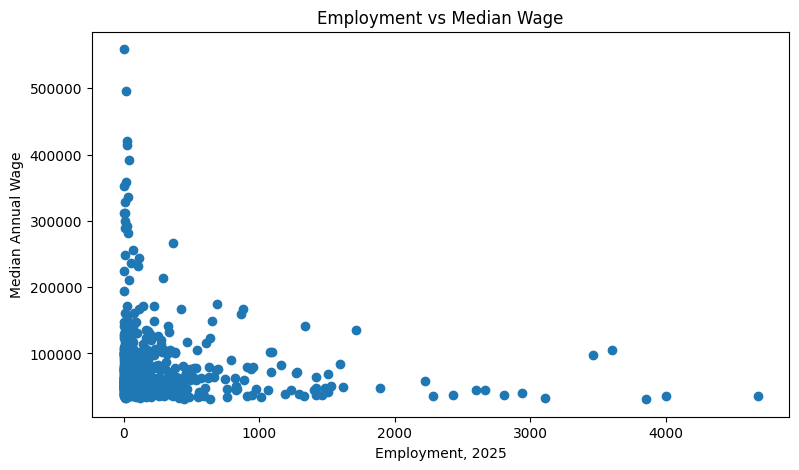

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,5))

plt.scatter(ml_data["Employment, 2025"], ml_data["A_MEDIAN"])

plt.xlabel("Employment, 2025")
plt.ylabel("Median Annual Wage")
plt.title("Employment vs Median Wage")

plt.show()

In [34]:
#Preparing data for simple linear regression
lr_data = ml_data[["Employment, 2025", "A_MEDIAN"]].dropna()
lr_data.shape

(825, 2)

In [35]:
X = lr_data[["Employment, 2025"]]
y = lr_data["A_MEDIAN"]

print(X.shape)
print(y.shape)

(825, 1)
(825,)


In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(660, 1)
(165, 1)
(660,)
(165,)


In [37]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

In [38]:
#Fitting the model to train on the data
lr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [39]:
#Coefficient: How much the predicted wage changes as employment changes.
#Intercept: Where the fitted line starts when employment is zero.

print("Coefficient:", lr_model.coef_[0])
print("Intercept:", lr_model.intercept_)

Coefficient: -9.213595100631437
Intercept: 75463.13112166978


In [40]:
#Now using the trained data to make predictions
y_pred = lr_model.predict(X_test)

In [41]:
# Calculating Mean Absolute Error (MAE) to measure the average absolute difference between actual and predicted wages
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

MAE: 35173.481473860695


In [42]:
# Calculating Root Mean Squared Error (RMSE) to measure prediction error while giving more weight to large errors
from sklearn.metrics import mean_squared_error

rmse = mean_squared_error(y_test, y_pred) ** 0.5

print("RMSE:", rmse)

RMSE: 57849.78827210393


In [43]:
# Calculating R² to measure how much of the variation in actual wages is explained by the model
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print("R²:", r2)

R²: -0.008353119913329099


In [44]:
# Selecting the labor-market features we will use to predict median occupational wage. Selecting the predictors and target together and removing rows with missing values
lr_multi_data = ml_data[["Employment, 2025", "OPENINGS_RATE", "Employment change, percent, 2025–35", "A_MEDIAN"]].dropna()

In [45]:
# Separating the predictor variables from the target variable
X = lr_multi_data[["Employment, 2025","OPENINGS_RATE", "Employment change, percent, 2025–35"]]

# Separating the target variable
y = lr_multi_data["A_MEDIAN"]

print(X.shape)
print(y.shape)

(825, 3)
(825,)


In [46]:
# Splitting the data into 80% training data and 20% testing data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [47]:
# Creating a Linear Regression model
from sklearn.linear_model import LinearRegression

lr_model_multi = LinearRegression()

In [48]:
#Fitting the model to train on the data
lr_model_multi.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [49]:
# Displaying the learned coefficient for each predictor
print("Employment coefficient:", lr_model_multi.coef_[0])
print("Openings rate coefficient:", lr_model_multi.coef_[1])
print("Growth coefficient:", lr_model_multi.coef_[2])

# Displaying the model intercept
print("Intercept:", lr_model_multi.intercept_)

Employment coefficient: -1.8322194092236845
Openings rate coefficient: -7519.39816288662
Growth coefficient: 1873.4482937977266
Intercept: 137763.09165223796


In [50]:
# Finding: Employment and openings rate had a negative relationship with wage,
#while projected growth had a positive relationship with wage.

In [51]:
#Now using the trained model to make predictions
y_pred_multi = lr_model_multi.predict(X_test)
print(y_pred_multi[:10])

[ 68538.4934918   88813.82377754  72611.62093734  51109.32225491
  86429.26000659 124221.13292819  81230.59924277 109986.51929023
  49745.93363475  46383.77265242]


In [52]:
# Calculating Mean Absolute Error (MAE) to measure the average difference between actual and predicted wages
#On average, how many dollars away are the predictions from the actual wages?
from sklearn.metrics import mean_absolute_error

mae_multi = mean_absolute_error(y_test, y_pred_multi)

print("MAE:", mae_multi)

MAE: 26572.90891034199


In [53]:
# Calculating Root Mean Squared Error (RMSE) to measure prediction error while giving more weight to large errors
from sklearn.metrics import mean_squared_error

rmse_multi = mean_squared_error(y_test, y_pred_multi) ** 0.5

print("RMSE:", rmse_multi)

RMSE: 45593.88718178221


In [54]:
# Calculating R² to measure how much variation in wages is explained by the model
#How much of the differences in wages can be explained by the model?
from sklearn.metrics import r2_score

r2_multi = r2_score(y_test, y_pred_multi)

print("R²:", r2_multi)

R²: 0.37364241735972903


In [55]:
# Comparing the simple and multivariable Linear Regression models

print("Model 1 - Employment only")
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

print("\nModel 2 - Employment + Openings Rate + Growth")
print("MAE:", mae_multi)
print("RMSE:", rmse_multi)
print("R²:", r2_multi)

Model 1 - Employment only
MAE: 35173.481473860695
RMSE: 57849.78827210393
R²: -0.008353119913329099

Model 2 - Employment + Openings Rate + Growth
MAE: 26572.90891034199
RMSE: 45593.88718178221
R²: 0.37364241735972903


In [56]:
# Finding: Adding openings rate and growth improved wage prediction.
# The model's errors decreased and R² increased to about 37%.
# Wage differences are better explained by multiple labor-market characteristics
# than by employment size alone.

In [57]:
#Creating an openings percentile column
ml_data["OPENINGS_PERCENTILE"] = ml_data["OPENINGS_RATE"].rank(pct=True)*100

In [58]:
ml_data[["OCC_TITLE", "OPENINGS_RATE", "OPENINGS_PERCENTILE"]].head(10)

,OCC_TITLE,OPENINGS_RATE,OPENINGS_PERCENTILE
0,Chief Executives,6.550069,19.879518
1,General and Operations Managers,7.918866,44.819277
2,Advertising and Promotions Managers,6.927711,26.987952
3,Marketing Managers,8.064516,46.807229
4,Sales Managers,7.275804,32.289157
5,Public Relations Managers,7.549505,38.072289
6,Fundraising Managers,7.581967,38.674699
7,Administrative Services Managers,7.885305,44.216867
8,Facilities Managers,8.559373,54.096386
9,Computer and Information Systems Managers,7.801108,42.650602


In [59]:
# Calculating the Opportunity Score as the average of all the four labor-market percentiles
ml_data["OPPORTUNITY_SCORE"] = (ml_data["WAGE_PERCENTILE"] + ml_data["EMPLOYMENT_PERCENTILE"]
+ ml_data["GROWTH_PERCENTILE"] + ml_data["OPENINGS_PERCENTILE"])/4

In [61]:
ml_data[["OCC_TITLE", "WAGE_PERCENTILE", "EMPLOYMENT_PERCENTILE", "GROWTH_PERCENTILE", "OPENINGS_PERCENTILE", 
"OPPORTUNITY_SCORE"]].head(10)

,OCC_TITLE,WAGE_PERCENTILE,EMPLOYMENT_PERCENTILE,GROWTH_PERCENTILE,OPENINGS_PERCENTILE,OPPORTUNITY_SCORE
0,Chief Executives,97.333333,83.614458,53.975904,19.879518,63.700803
1,General and Operations Managers,87.030303,99.638554,71.265060,44.819277,75.688299
2,Advertising and Promotions Managers,93.212121,40.963855,15.000000,26.987952,44.040982
3,Marketing Managers,96.363636,88.433735,84.698795,46.807229,79.075849
4,Sales Managers,95.393939,92.771084,67.289157,32.289157,71.935834
5,Public Relations Managers,94.909091,60.481928,77.108434,38.072289,67.642935
6,Fundraising Managers,91.757576,49.036145,74.156627,38.674699,63.406261
7,Administrative Services Managers,89.333333,83.132530,72.831325,44.216867,72.378514
8,Facilities Managers,87.757576,75.421687,67.710843,54.096386,71.246623
9,Computer and Information Systems Managers,96.969697,93.132530,97.108434,42.650602,82.465316


In [67]:
# Creating a function to label classify occupations based on their Opportunity Score
def classify_opportunity(score):
    if score < 50:
        return 'Low'
    elif score < 65:
        return 'Medium'
    else:
        return 'High'

ml_data["OPPORTUNITY_CATEGORY"] = ml_data["OPPORTUNITY_SCORE"].apply(classify_opportunity)

ml_data[["OCC_TITLE", "WAGE_PERCENTILE", "EMPLOYMENT_PERCENTILE", "GROWTH_PERCENTILE", "OPENINGS_PERCENTILE", 
"OPPORTUNITY_SCORE", "OPPORTUNITY_CATEGORY"]].head(10)

,OCC_TITLE,WAGE_PERCENTILE,EMPLOYMENT_PERCENTILE,GROWTH_PERCENTILE,OPENINGS_PERCENTILE,OPPORTUNITY_SCORE,OPPORTUNITY_CATEGORY
0,Chief Executives,97.333333,83.614458,53.975904,19.879518,63.700803,Medium
1,General and Operations Managers,87.030303,99.638554,71.265060,44.819277,75.688299,High
2,Advertising and Promotions Managers,93.212121,40.963855,15.000000,26.987952,44.040982,Low
3,Marketing Managers,96.363636,88.433735,84.698795,46.807229,79.075849,High
4,Sales Managers,95.393939,92.771084,67.289157,32.289157,71.935834,High
5,Public Relations Managers,94.909091,60.481928,77.108434,38.072289,67.642935,High
6,Fundraising Managers,91.757576,49.036145,74.156627,38.674699,63.406261,Medium
7,Administrative Services Managers,89.333333,83.132530,72.831325,44.216867,72.378514,High
8,Facilities Managers,87.757576,75.421687,67.710843,54.096386,71.246623,High
9,Computer and Information Systems Managers,96.969697,93.132530,97.108434,42.650602,82.465316,High


In [68]:
# Checking how many occupations are in each opportunity category
print(ml_data["OPPORTUNITY_CATEGORY"].value_counts())

OPPORTUNITY_CATEGORY
Low       410
Medium    291
High      129
Name: count, dtype: int64


In [70]:
# Selecting the labor-market features used to classify opportunity
X = ml_data[["WAGE_PERCENTILE", "EMPLOYMENT_PERCENTILE", "GROWTH_PERCENTILE", "OPENINGS_PERCENTILE"]].dropna()

# Selecting the opportunity category we want the model to predict
#Using loc because the rows in y should map exactly to X
y = ml_data.loc[X.index, "OPPORTUNITY_CATEGORY"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (825, 4)
y shape: (825,)


In [81]:
# Splitting the data into training data (80%) and test data (20%)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(660, 4)
(165, 4)
(660,)
(165,)


In [72]:
# Creating the Decision Tree classification model
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(random_state=42)

In [73]:
# Training the Decision Tree using the training data
tree_model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [74]:
# Predicting opportunity categories for the unseen test occupations
y_pred_tree = tree_model.predict(X_test)

print(y_pred_tree[:10])

['Low' 'Medium' 'Medium' 'Medium' 'Low' 'Medium' 'Medium' 'High' 'Medium'
 'Low']


In [76]:
# Calculating the percentage of test occupations classified correctly
from sklearn.metrics import accuracy_score

accuracy_tree = accuracy_score(y_test, y_pred_tree)

print("Decision Tree Accuracy:", accuracy_tree)

Decision Tree Accuracy: 0.8424242424242424


In [77]:
# Comparing actual and predicted opportunity categories
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_tree, labels=["Low", "Medium", "High"])

print(cm)

[[74  8  0]
 [ 7 45  6]
 [ 0  5 20]]


In [78]:
# Finding: The Decision Tree correctly classified most occupations,
# with 74 Low, 45 Medium, and 20 High occupations classified correctly.

In [80]:
from sklearn.metrics import classification_report

# Evaluating how well the Decision Tree classified each opportunity category
print(classification_report(y_test, y_pred_tree, labels=["Low", "Medium", "High"]))

              precision    recall  f1-score   support

         Low       0.91      0.90      0.91        82
      Medium       0.78      0.78      0.78        58
        High       0.77      0.80      0.78        25

    accuracy                           0.84       165
   macro avg       0.82      0.83      0.82       165
weighted avg       0.84      0.84      0.84       165



In [83]:
# Selecting labor-market features for K-Means clustering
X_kmeans = ml_data[["WAGE_PERCENTILE","EMPLOYMENT_PERCENTILE", "GROWTH_PERCENTILE", "OPENINGS_PERCENTILE"]].dropna()

print("K-Means data shape:", X_kmeans.shape)

K-Means data shape: (825, 4)


In [84]:
# Creating a K-Means model with 3 labor-market clusters. 3 groups of occupations that are similar to each other.
from sklearn.cluster import KMeans

kmeans_model = KMeans(n_clusters=3, random_state=42, n_init=10)

In [85]:
# Training K-Means and finding the 3 labor-market clusters
kmeans_model.fit(X_kmeans)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [86]:
# Assigning each occupation to its K-Means cluster
ml_data.loc[X_kmeans.index, "KMEANS_CLUSTER"] = kmeans_model.labels_

In [87]:
# Checking the number of occupations in each cluster
print(ml_data["KMEANS_CLUSTER"].value_counts())

KMEANS_CLUSTER
0.0    322
1.0    258
2.0    245
Name: count, dtype: int64


In [88]:
# Comparing the average labor-market characteristics of each cluster
cluster_summary = ml_data.groupby("KMEANS_CLUSTER")[["WAGE_PERCENTILE", "EMPLOYMENT_PERCENTILE",
"GROWTH_PERCENTILE", "OPENINGS_PERCENTILE"]].mean()

print(cluster_summary)

                WAGE_PERCENTILE  EMPLOYMENT_PERCENTILE  GROWTH_PERCENTILE  \
KMEANS_CLUSTER                                                              
0.0                   77.532844              52.125271          62.738158   
1.0                   37.303030              30.157841          22.619548   
2.0                   27.388745              68.405950          62.375215   

                OPENINGS_PERCENTILE  
KMEANS_CLUSTER                       
0.0                       25.473135  
1.0                       53.739610  
2.0                       78.019425  


In [89]:
# Finding: K-Means identified three distinct labor-market profiles.
# One group has higher wages, another has weaker wages and growth,
# while the third has high employment, growth, and openings but lower wages.